# Data Analyst Job Market Intelligence: Skill, Experience & Salary Analytics — India

## Python Statistical Analysis

This notebook analyzes the validated analytical dataset produced by the project pipeline.

### Analytical goals
- validate the processed dataset and analytical coverage;
- quantify role, city, employer, skill, experience, and work-mode demand;
- measure skill co-occurrence;
- analyze advertised salary only for rows marked `salary_analysis_eligible`;
- compare SQL-tagged and non-SQL salary observations using a 50,000-iteration bootstrap;
- evaluate exploratory skill-salary associations using minimum sample rules;
- examine complete-week hiring and skill-demand trends;
- compare the recent 90-day market with the pre-90-day period.

### Reporting rules
- missing salary values are not imputed;
- salary by role and city requires `n >= 30`;
- exploratory skill salary analysis requires `n >= 10`;
- experience salary analysis requires `n >= 20`;
- confidence intervals containing zero are reported as statistically inconclusive;
- trend slopes are descriptive signals and are not forecasts;
- salary associations are not interpreted as causal effects.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)

PROJECT_TITLE = "Data Analyst Job Market Intelligence: Skill, Experience & Salary Analytics — India"
pd.set_option("display.width", 160)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

JOBS_FILE = PROJECT_ROOT / "data" / "processed" / "job_postings_clean.csv"
SKILLS_FILE = PROJECT_ROOT / "data" / "processed" / "job_skills_bridge.csv"

REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURE_DIR = REPORTS_DIR / "figures"

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

EXPECTED_JOBS = 4_035
EXPECTED_SKILL_ROWS = 6_213
EXPECTED_SKILLS = 44
EXPECTED_SALARY_ROWS = 110

ROLE_CITY_MIN_N = 30
SKILL_SALARY_MIN_N = 10
EXPERIENCE_SALARY_MIN_N = 20
BOOTSTRAP_ITERATIONS = 50_000
RANDOM_SEED = 42

jobs = pd.read_csv(JOBS_FILE, low_memory=False)
skills = pd.read_csv(SKILLS_FILE, low_memory=False)

jobs["posted_date"] = pd.to_datetime(jobs["posted_date"], errors="coerce")

if "week_start" in jobs.columns:
    jobs["week_start"] = pd.to_datetime(jobs["week_start"], errors="coerce")
else:
    jobs["week_start"] = (
        jobs["posted_date"]
        - pd.to_timedelta(jobs["posted_date"].dt.weekday, unit="D")
    )

for column in [
    "experience_min_years",
    "experience_max_years",
    "salary_min_source",
    "salary_max_source",
    "salary_min",
    "salary_max",
    "salary_midpoint",
]:
    if column in jobs.columns:
        jobs[column] = pd.to_numeric(jobs[column], errors="coerce")

for column in [
    "has_salary_source",
    "salary_analysis_eligible",
    "has_extracted_skill",
    "is_recent_90d",
    "is_complete_week",
]:
    if column in jobs.columns:
        jobs[column] = (
            jobs[column]
            .astype(str)
            .str.strip()
            .str.lower()
            .map({
                "true": True,
                "false": False,
                "1": True,
                "0": False,
                "yes": True,
                "no": False,
            })
            .fillna(False)
            .astype(bool)
        )

print("Jobs file:", JOBS_FILE)
print("Skills file:", SKILLS_FILE)
print(f"Jobs loaded: {len(jobs):,}")
print(f"Job-skill rows loaded: {len(skills):,}")


Jobs file: C:\Users\kvina\Downloads\Data Analyst Job Market Intelligence Skill, Experience and Salary Analytics — India\Data Analyst Job Market Intelligence Skill, Experience and Salary Analytics — India\data\processed\job_postings_clean.csv
Skills file: C:\Users\kvina\Downloads\Data Analyst Job Market Intelligence Skill, Experience and Salary Analytics — India\Data Analyst Job Market Intelligence Skill, Experience and Salary Analytics — India\data\processed\job_skills_bridge.csv
Jobs loaded: 4,035
Job-skill rows loaded: 6,213


## 1. Dataset integrity and analytical coverage


In [2]:
required_job_columns = {
    "job_id",
    "title",
    "company_name",
    "city",
    "state",
    "location_scope",
    "role_family",
    "work_mode",
    "posted_date",
    "is_recent_90d",
    "is_complete_week",
    "experience_min_years",
    "experience_band",
    "salary_min",
    "salary_max",
    "salary_midpoint",
    "has_salary_source",
    "salary_analysis_eligible",
    "skill_count",
    "has_extracted_skill",
}

required_skill_columns = {
    "job_id",
    "skill",
    "skill_category",
}

missing_job_columns = sorted(required_job_columns - set(jobs.columns))
missing_skill_columns = sorted(required_skill_columns - set(skills.columns))

assert not missing_job_columns, f"Missing job columns: {missing_job_columns}"
assert not missing_skill_columns, f"Missing skill columns: {missing_skill_columns}"

assert len(jobs) == EXPECTED_JOBS
assert len(skills) == EXPECTED_SKILL_ROWS
assert skills["skill"].nunique() == EXPECTED_SKILLS
assert jobs["job_id"].astype("string").duplicated().sum() == 0
assert skills.duplicated(["job_id", "skill"]).sum() == 0
assert set(skills["job_id"].astype(str)).issubset(set(jobs["job_id"].astype(str)))

salary_jobs = jobs.loc[jobs["salary_analysis_eligible"]].copy()
assert len(salary_jobs) == EXPECTED_SALARY_ROWS
assert salary_jobs[["salary_min", "salary_max", "salary_midpoint"]].notna().all().all()
assert (salary_jobs["salary_min"] > 0).all()
assert (salary_jobs["salary_max"] > 0).all()
assert (salary_jobs["salary_max"] >= salary_jobs["salary_min"]).all()

placeholder_names = {
    "testhiring",
    "test",
    "demo",
    "sample company",
    "xyz company",
    "abc company",
    "dummy",
}

placeholder_count = (
    jobs["company_name"]
    .astype("string")
    .str.strip()
    .str.lower()
    .isin(placeholder_names)
    .sum()
)
assert placeholder_count == 0

overview = pd.DataFrame(
    {
        "Metric": [
            "Analytical vacancies",
            "Job-skill rows",
            "Unique extracted skills",
            "Skill-tagged jobs",
            "Skill coverage",
            "Experience-labeled jobs",
            "Experience coverage",
            "Salary-source jobs",
            "Salary-source coverage",
            "Salary-analysis jobs",
            "Salary-analysis coverage",
            "Recent 90-day jobs",
            "Complete-week jobs",
        ],
        "Value": [
            f"{len(jobs):,}",
            f"{len(skills):,}",
            f"{skills['skill'].nunique():,}",
            f"{jobs['has_extracted_skill'].sum():,}",
            f"{jobs['has_extracted_skill'].mean() * 100:.2f}%",
            f"{jobs['experience_min_years'].notna().sum():,}",
            f"{jobs['experience_min_years'].notna().mean() * 100:.2f}%",
            f"{jobs['has_salary_source'].sum():,}",
            f"{jobs['has_salary_source'].mean() * 100:.2f}%",
            f"{jobs['salary_analysis_eligible'].sum():,}",
            f"{jobs['salary_analysis_eligible'].mean() * 100:.2f}%",
            f"{jobs['is_recent_90d'].sum():,}",
            f"{jobs['is_complete_week'].sum():,}",
        ],
    }
)

display(overview)
print("Integrity checks: PASS")


,Metric,Value
0,Analytical vacancies,"4,035"
1,Job-skill rows,"6,213"
2,Unique extracted skills,44
3,Skill-tagged jobs,"1,744"
4,Skill coverage,43.22%
5,Experience-labeled jobs,"1,425"
6,Experience coverage,35.32%
7,Salary-source jobs,121
8,Salary-source coverage,3.00%
9,Salary-analysis jobs,110


Integrity checks: PASS


## 2. Role demand


,role_family,job_count,market_share_pct,cumulative_share_pct
0,Business Analyst,1541,38.190830,38.190830
1,Data Analyst,831,20.594796,58.785626
2,Other Analyst,388,9.615861,68.401487
3,Operations / Process Analytics,330,8.178439,76.579926
4,BI Analyst,178,4.411400,80.991326
5,Risk / Quantitative Analytics,175,4.337051,85.328377
6,Product Analyst,131,3.246592,88.574969
7,Reporting / MIS Analyst,118,2.924411,91.499380
8,Data Quality / Governance,116,2.874845,94.374226
9,Pricing / Revenue / Commercial,88,2.180917,96.555143


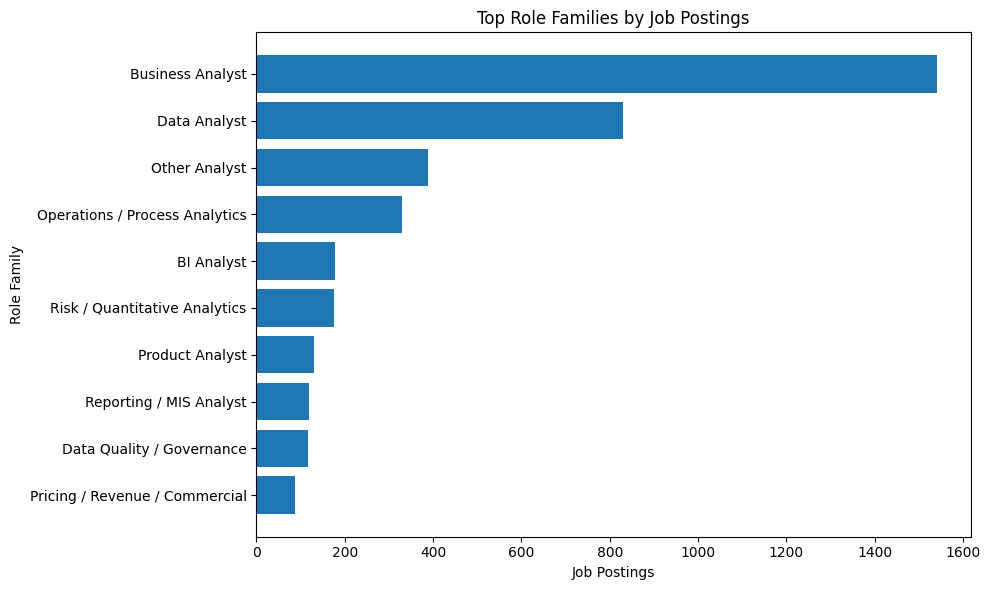

In [3]:
role_demand = (
    jobs["role_family"]
    .fillna("Not Specified")
    .value_counts()
    .rename_axis("role_family")
    .reset_index(name="job_count")
)

role_demand["market_share_pct"] = (
    role_demand["job_count"]
    / len(jobs)
    * 100
)

role_demand["cumulative_share_pct"] = (
    role_demand["market_share_pct"].cumsum()
)

display(role_demand)

plt.figure(figsize=(10, 6))
plot_df = role_demand.head(10).sort_values("job_count")
plt.barh(plot_df["role_family"], plot_df["job_count"])
plt.title("Top Role Families by Job Postings")
plt.xlabel("Job Postings")
plt.ylabel("Role Family")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "01_role_distribution.png", dpi=160, bbox_inches="tight")
plt.show()


## 3. Location and employer demand


Top cities


,city,state,job_count
14,Bengaluru,Karnataka,1073
42,Hyderabad,Telangana,540
65,Mumbai,Maharashtra,348
77,Pune,Maharashtra,334
38,Gurugram,Haryana,202
22,Chennai,Tamil Nadu,155
72,Noida,Uttar Pradesh,132
29,Delhi,Delhi,38
3,Ahmedabad,Gujarat,35
89,Thane,Maharashtra,21


Top employers


,company_name,job_count
93,Amazon,134
484,Genpact,116
366,EXL,82
107,Amgen,80
609,JPMorganChase,78
51,Accenture,69
256,Citigroup,65
178,Barclays,62
58,Acura Solution,31
255,Citi,29


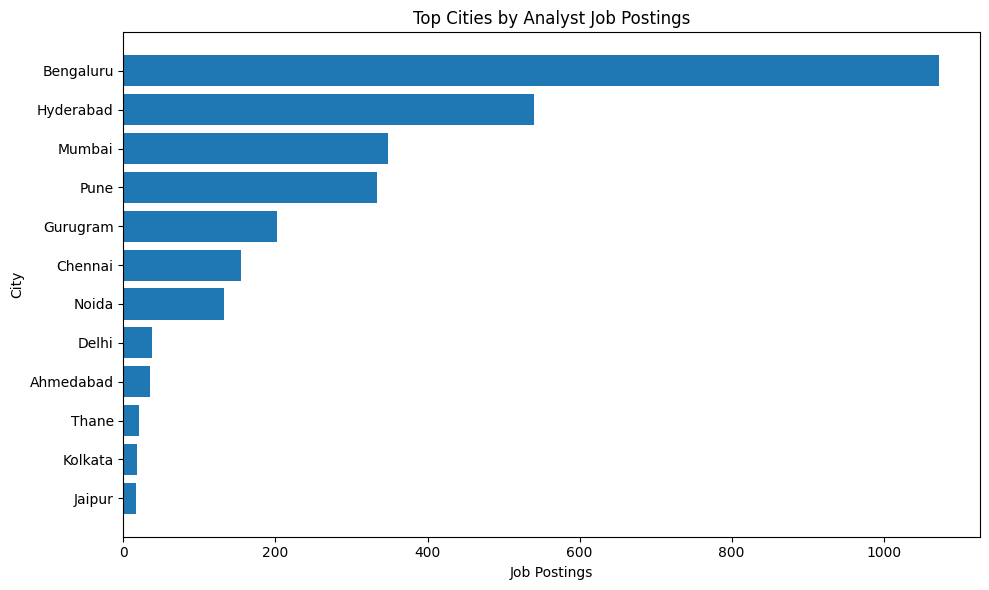

In [4]:
specific_city_jobs = jobs.loc[
    jobs["location_scope"].eq("Specific City")
].copy()

city_demand = (
    specific_city_jobs
    .groupby(["city", "state"], dropna=False)
    .size()
    .reset_index(name="job_count")
    .sort_values(["job_count", "city"], ascending=[False, True])
)

company_demand = (
    jobs.loc[
        jobs["company_name"].fillna("Unknown Company").ne("Unknown Company")
    ]
    .groupby("company_name")
    .size()
    .reset_index(name="job_count")
    .sort_values(["job_count", "company_name"], ascending=[False, True])
)

print("Top cities")
display(city_demand.head(15))

print("Top employers")
display(company_demand.head(20))

plt.figure(figsize=(10, 6))
plot_df = city_demand.head(12).sort_values("job_count")
plt.barh(plot_df["city"], plot_df["job_count"])
plt.title("Top Cities by Analyst Job Postings")
plt.xlabel("Job Postings")
plt.ylabel("City")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "02_city_demand.png", dpi=160, bbox_inches="tight")
plt.show()


## 4. Work mode and experience demand


Work mode


,work_mode,job_count,share_pct
0,Not Specified,3379,83.742255
1,Hybrid,345,8.550186
2,Remote,209,5.179678
3,On-site,102,2.527881


Experience bands


,experience_band,job_count,share_pct
0,0–1,36,0.892193
1,1–2,113,2.800496
2,2–3,245,6.071871
3,3–4,304,7.534077
4,4–5,143,3.543990
5,5–6,289,7.162330
6,6–7,87,2.156134
7,7–8,68,1.685254
8,8–9,79,1.957869
9,9–10,5,0.123916


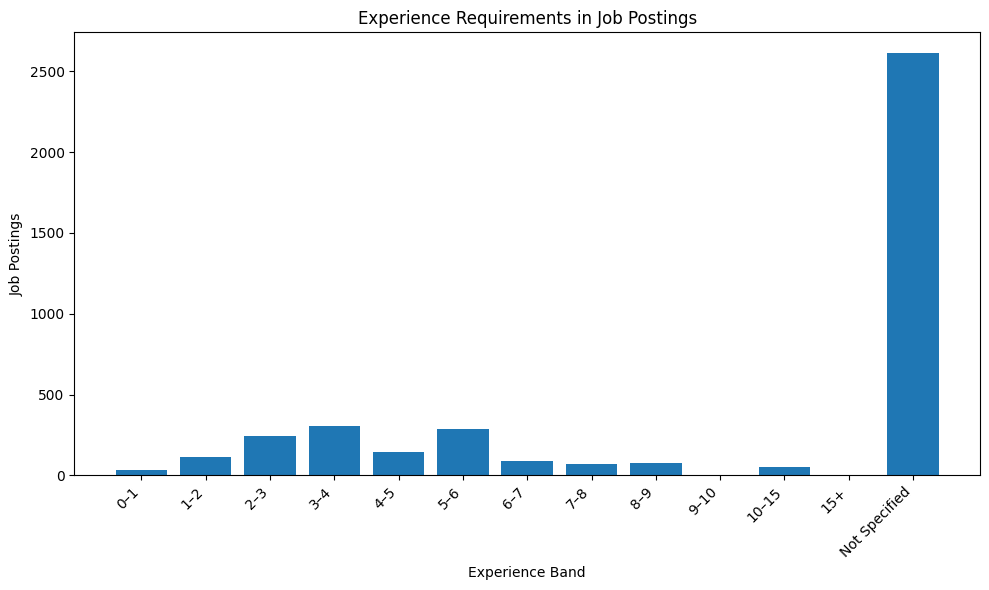

In [5]:
work_mode = (
    jobs["work_mode"]
    .fillna("Not Specified")
    .value_counts()
    .rename_axis("work_mode")
    .reset_index(name="job_count")
)
work_mode["share_pct"] = work_mode["job_count"] / len(jobs) * 100

experience_order = [
    "0–1",
    "1–2",
    "2–3",
    "3–4",
    "4–5",
    "5–6",
    "6–7",
    "7–8",
    "8–9",
    "9–10",
    "10–15",
    "15+",
    "Not Specified",
]

experience = (
    jobs["experience_band"]
    .fillna("Not Specified")
    .value_counts()
    .reindex(experience_order, fill_value=0)
    .rename_axis("experience_band")
    .reset_index(name="job_count")
)
experience["share_pct"] = experience["job_count"] / len(jobs) * 100

print("Work mode")
display(work_mode)

print("Experience bands")
display(experience)

plt.figure(figsize=(10, 6))
plot_df = experience.loc[experience["job_count"] > 0]
plt.bar(plot_df["experience_band"], plot_df["job_count"])
plt.title("Experience Requirements in Job Postings")
plt.xlabel("Experience Band")
plt.ylabel("Job Postings")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "03_experience_distribution.png", dpi=160, bbox_inches="tight")
plt.show()


## 5. Skill demand


,skill,skill_category,job_count,share_of_all_jobs_pct,share_of_skill_tagged_jobs_pct
35,SQL,Database / Query,850,21.065675,48.738532
12,Excel,Spreadsheet,624,15.464684,35.779817
25,Power BI,BI / Visualization,586,14.522924,33.600917
27,Python,Programming,527,13.060719,30.217890
42,Tableau,BI / Visualization,420,10.408922,24.082569
41,Statistics,Statistics / Analytics,354,8.773234,20.298165
17,Jira,Collaboration Tool,227,5.625774,13.016055
32,SAP,Enterprise Tool,207,5.130112,11.869266
13,Forecasting,Statistics / Analytics,195,4.832714,11.181193
7,Data Modeling,Data Engineering,192,4.758364,11.009174


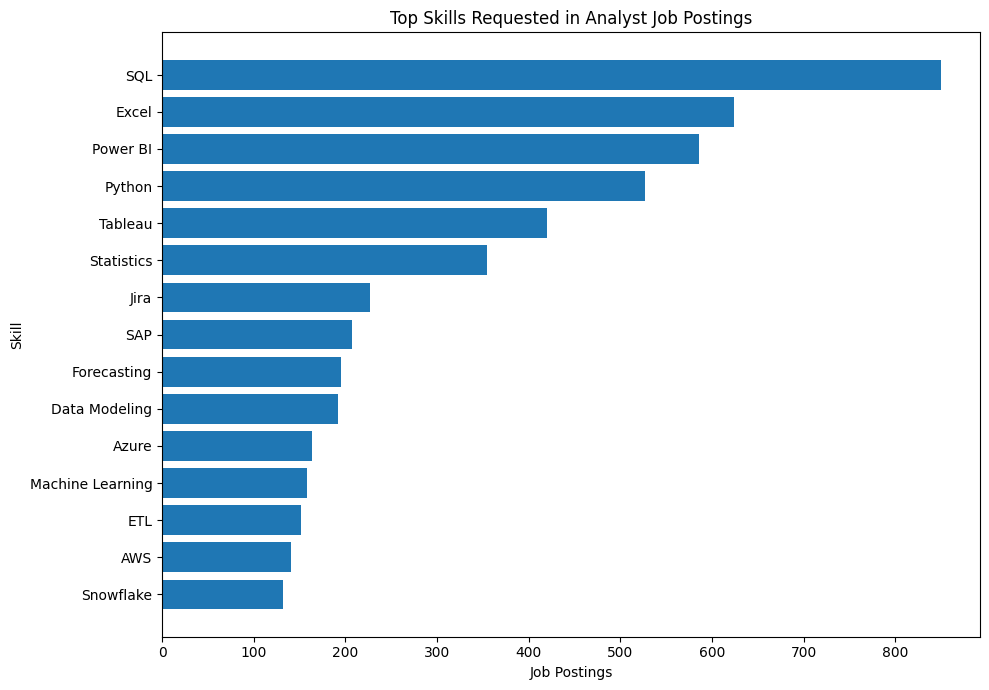

In [6]:
skill_counts = (
    skills.groupby(["skill", "skill_category"])["job_id"]
    .nunique()
    .reset_index(name="job_count")
    .sort_values(["job_count", "skill"], ascending=[False, True])
)

skill_tagged_jobs = int(jobs["has_extracted_skill"].sum())

skill_counts["share_of_all_jobs_pct"] = (
    skill_counts["job_count"] / len(jobs) * 100
)

skill_counts["share_of_skill_tagged_jobs_pct"] = (
    skill_counts["job_count"] / skill_tagged_jobs * 100
)

display(skill_counts.head(25))

plt.figure(figsize=(10, 7))
plot_df = skill_counts.head(15).sort_values("job_count")
plt.barh(plot_df["skill"], plot_df["job_count"])
plt.title("Top Skills Requested in Analyst Job Postings")
plt.xlabel("Job Postings")
plt.ylabel("Skill")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "04_top_skills.png", dpi=160, bbox_inches="tight")
plt.show()


## 6. Skill co-occurrence


,skill_1,skill_2,jobs_with_pair
4,Python,SQL,420
24,Power BI,SQL,383
12,Excel,SQL,330
6,SQL,Tableau,323
47,Power BI,Tableau,271
1,Excel,Power BI,262
59,Power BI,Python,253
80,SQL,Statistics,234
5,Python,Tableau,225
113,Python,Statistics,196


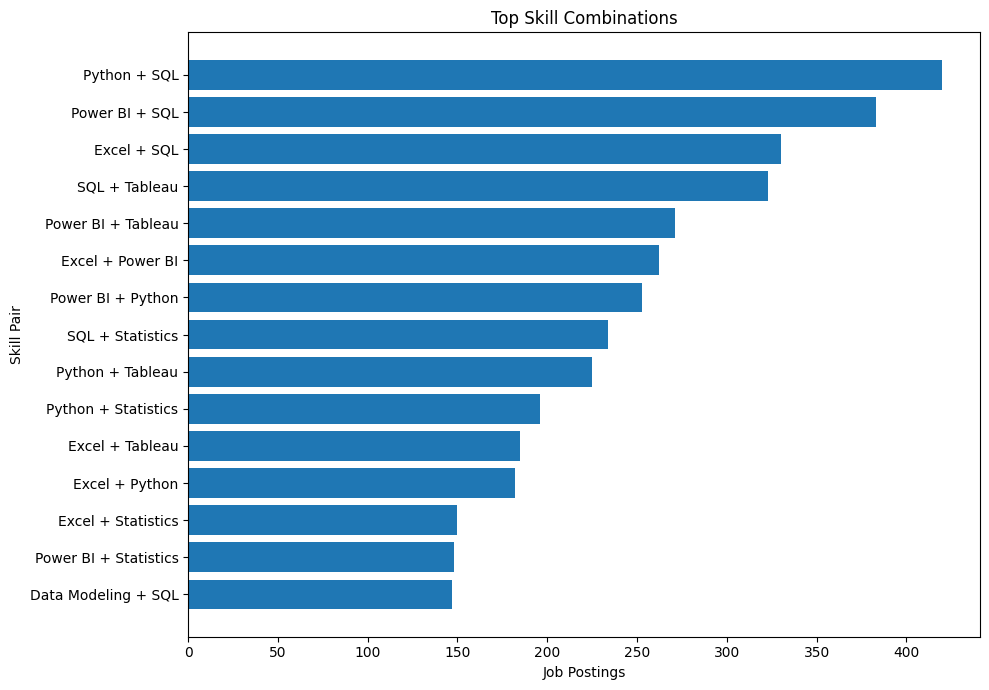

In [7]:
job_skill_sets = (
    skills.groupby("job_id")["skill"]
    .apply(lambda x: sorted(set(x.dropna().astype(str))))
)

pair_counts = {}

for skill_list in job_skill_sets:
    for i in range(len(skill_list)):
        for j in range(i + 1, len(skill_list)):
            pair = (skill_list[i], skill_list[j])
            pair_counts[pair] = pair_counts.get(pair, 0) + 1

skill_pairs = pd.DataFrame(
    [
        {
            "skill_1": pair[0],
            "skill_2": pair[1],
            "jobs_with_pair": count,
        }
        for pair, count in pair_counts.items()
    ]
).sort_values(
    ["jobs_with_pair", "skill_1", "skill_2"],
    ascending=[False, True, True],
)

display(skill_pairs.head(30))

plt.figure(figsize=(10, 7))
plot_df = skill_pairs.head(15).copy()
plot_df["pair"] = plot_df["skill_1"] + " + " + plot_df["skill_2"]
plot_df = plot_df.sort_values("jobs_with_pair")
plt.barh(plot_df["pair"], plot_df["jobs_with_pair"])
plt.title("Top Skill Combinations")
plt.xlabel("Job Postings")
plt.ylabel("Skill Pair")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "05_skill_cooccurrence.png", dpi=160, bbox_inches="tight")
plt.show()


## 7. Salary distribution


,Metric,Value
0,Salary observations,1.100000e+02
1,Minimum,2.700000e+05
2,25th percentile,5.425000e+05
3,Median,9.500000e+05
4,Mean,1.163505e+06
5,75th percentile,1.637500e+06
6,Maximum,4.200000e+06
7,At or above ₹30L,6.000000e+00


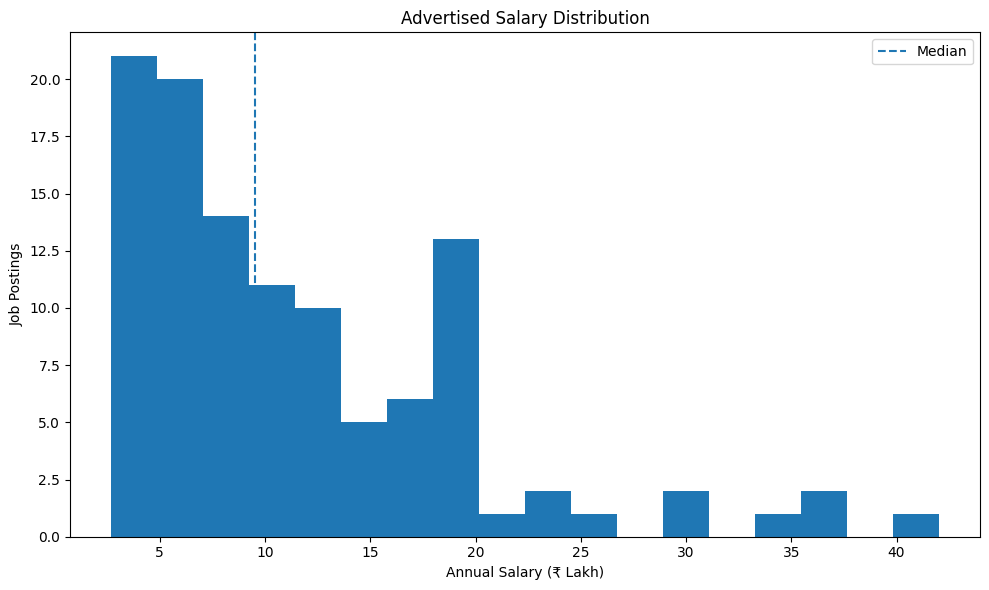

In [8]:
salary_summary = pd.DataFrame(
    {
        "Metric": [
            "Salary observations",
            "Minimum",
            "25th percentile",
            "Median",
            "Mean",
            "75th percentile",
            "Maximum",
            "At or above ₹30L",
        ],
        "Value": [
            len(salary_jobs),
            salary_jobs["salary_midpoint"].min(),
            salary_jobs["salary_midpoint"].quantile(0.25),
            salary_jobs["salary_midpoint"].median(),
            salary_jobs["salary_midpoint"].mean(),
            salary_jobs["salary_midpoint"].quantile(0.75),
            salary_jobs["salary_midpoint"].max(),
            int((salary_jobs["salary_midpoint"] >= 3_000_000).sum()),
        ],
    }
)

display(salary_summary)

plt.figure(figsize=(10, 6))
plt.hist(salary_jobs["salary_midpoint"] / 100000, bins=18)
plt.axvline(
    salary_jobs["salary_midpoint"].median() / 100000,
    linestyle="--",
    linewidth=1.5,
    label="Median",
)
plt.title("Advertised Salary Distribution")
plt.xlabel("Annual Salary (₹ Lakh)")
plt.ylabel("Job Postings")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "06_salary_distribution.png", dpi=160, bbox_inches="tight")
plt.show()


## 8. Salary by role, city, and experience with minimum sample rules


In [9]:
def grouped_salary_summary(
    frame,
    group_columns,
    min_n,
):
    summary = (
        frame.groupby(group_columns)["salary_midpoint"]
        .agg(
            salary_n="size",
            median_salary="median",
            mean_salary="mean",
        )
        .reset_index()
    )

    return (
        summary.loc[summary["salary_n"] >= min_n]
        .sort_values(
            ["median_salary", "salary_n"],
            ascending=[False, False],
        )
        .reset_index(drop=True)
    )

salary_by_role = grouped_salary_summary(
    salary_jobs,
    ["role_family"],
    ROLE_CITY_MIN_N,
)

salary_by_city = grouped_salary_summary(
    salary_jobs.loc[
        salary_jobs["location_scope"].eq("Specific City")
    ],
    ["city", "state"],
    ROLE_CITY_MIN_N,
)

salary_by_experience = grouped_salary_summary(
    salary_jobs.loc[
        salary_jobs["experience_band"].ne("Not Specified")
    ],
    ["experience_band"],
    EXPERIENCE_SALARY_MIN_N,
)

print(f"Salary by role, n >= {ROLE_CITY_MIN_N}")
display(salary_by_role)

print(f"Salary by city, n >= {ROLE_CITY_MIN_N}")
display(salary_by_city)

print(f"Salary by experience, n >= {EXPERIENCE_SALARY_MIN_N}")
display(salary_by_experience)


Salary by role, n >= 30


,role_family,salary_n,median_salary,mean_salary
0,Business Analyst,61,1000000.0,1.150869e+06


Salary by city, n >= 30


,city,state,salary_n,median_salary,mean_salary


Salary by experience, n >= 20


,experience_band,salary_n,median_salary,mean_salary


## 9. Exploratory skill-salary associations


,skill,salary_n,median_salary,mean_salary,median_difference_vs_overall_pct
0,SQL,18,1341250.0,1.478194e+06,41.184211


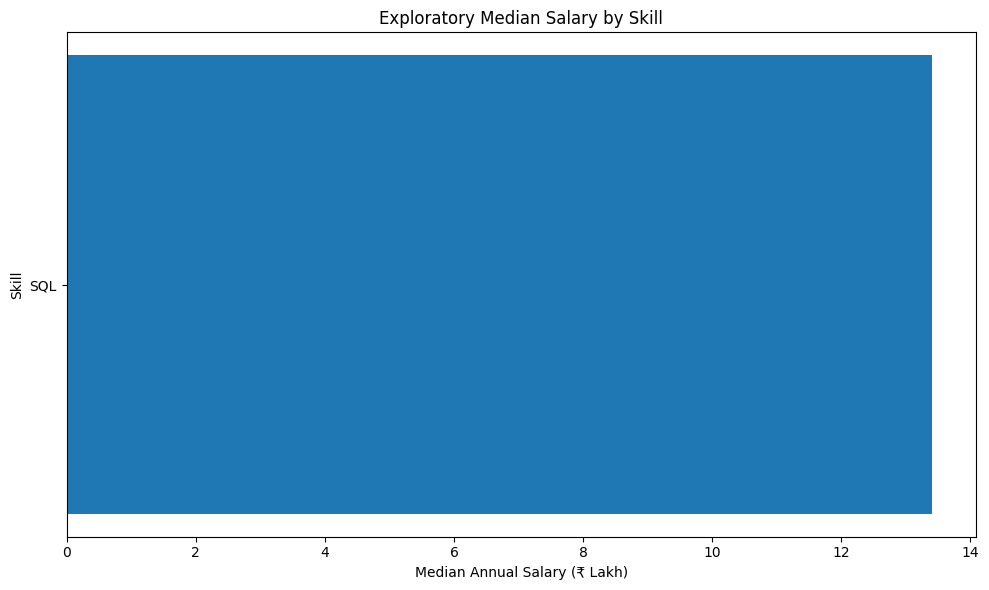

In [10]:
salary_skill = skills.merge(
    salary_jobs[
        [
            "job_id",
            "salary_midpoint",
        ]
    ],
    on="job_id",
    how="inner",
)

skill_salary = (
    salary_skill.groupby("skill")
    .agg(
        salary_n=("job_id", "nunique"),
        median_salary=("salary_midpoint", "median"),
        mean_salary=("salary_midpoint", "mean"),
    )
    .reset_index()
)

overall_salary_median = salary_jobs["salary_midpoint"].median()

skill_salary["median_difference_vs_overall_pct"] = (
    (
        skill_salary["median_salary"]
        - overall_salary_median
    )
    / overall_salary_median
    * 100
)

qualifying_skill_salary = (
    skill_salary.loc[
        skill_salary["salary_n"] >= SKILL_SALARY_MIN_N
    ]
    .sort_values(
        ["median_salary", "salary_n"],
        ascending=[False, False],
    )
    .reset_index(drop=True)
)

display(qualifying_skill_salary)

if not qualifying_skill_salary.empty:
    plt.figure(figsize=(10, 6))
    plot_df = qualifying_skill_salary.sort_values("median_salary")
    plt.barh(
        plot_df["skill"],
        plot_df["median_salary"] / 100000,
    )
    plt.title("Exploratory Median Salary by Skill")
    plt.xlabel("Median Annual Salary (₹ Lakh)")
    plt.ylabel("Skill")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "07_skill_salary.png", dpi=160, bbox_inches="tight")
    plt.show()
else:
    print("No skill met the exploratory salary sample threshold.")


## 10. SQL vs non-SQL advertised salary


In [11]:
sql_job_ids = set(
    skills.loc[
        skills["skill"].astype(str).str.upper().eq("SQL"),
        "job_id",
    ].astype(str)
)

salary_jobs["has_sql"] = (
    salary_jobs["job_id"]
    .astype(str)
    .isin(sql_job_ids)
)

sql_salary = (
    salary_jobs.loc[
        salary_jobs["has_sql"],
        "salary_midpoint",
    ]
    .dropna()
    .to_numpy()
)

non_sql_salary = (
    salary_jobs.loc[
        ~salary_jobs["has_sql"],
        "salary_midpoint",
    ]
    .dropna()
    .to_numpy()
)

sql_comparison = pd.DataFrame(
    {
        "Group": ["SQL", "Non-SQL"],
        "n": [len(sql_salary), len(non_sql_salary)],
        "Median Salary": [
            np.median(sql_salary) if len(sql_salary) else np.nan,
            np.median(non_sql_salary) if len(non_sql_salary) else np.nan,
        ],
        "Mean Salary": [
            np.mean(sql_salary) if len(sql_salary) else np.nan,
            np.mean(non_sql_salary) if len(non_sql_salary) else np.nan,
        ],
    }
)

display(sql_comparison)

observed_sql_median_difference = (
    np.median(sql_salary)
    - np.median(non_sql_salary)
)

print(
    "Observed median difference, SQL minus Non-SQL:",
    f"₹{observed_sql_median_difference:,.0f}",
)


,Group,n,Median Salary,Mean Salary
0,SQL,18,1341250.0,1.478194e+06
1,Non-SQL,92,862500.0,1.101935e+06


Observed median difference, SQL minus Non-SQL: ₹478,750


## 11. 50,000-iteration bootstrap for the SQL median difference


,Metric,Value
0,Bootstrap iterations,50000
1,Observed median difference,478750.0
2,95% CI lower bound,-75000.0
3,95% CI upper bound,1100000.0
4,CI includes zero,True


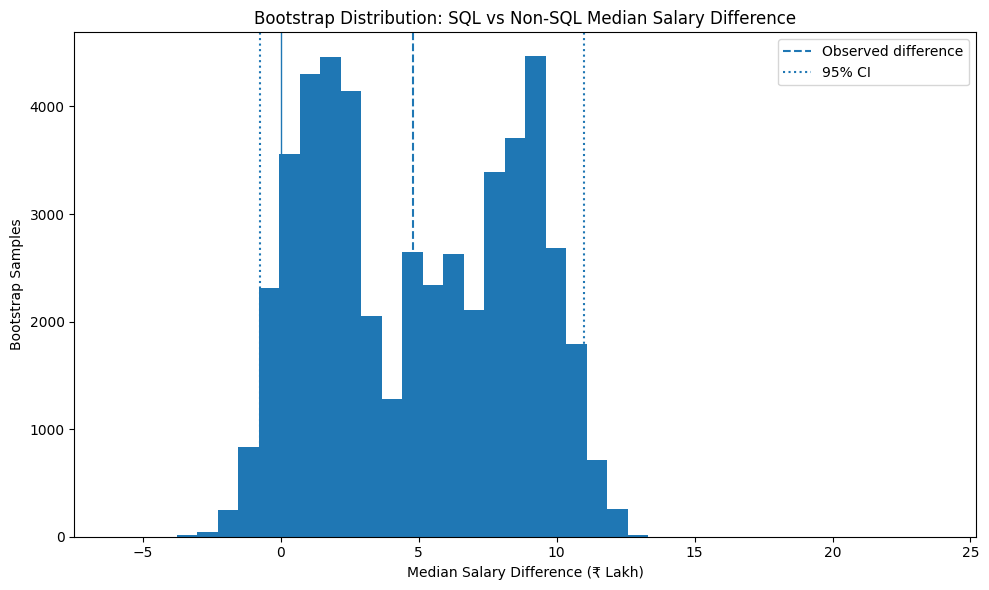

Interpretation: the confidence interval includes zero, so the observed salary difference is statistically inconclusive.


In [12]:
assert len(sql_salary) > 0
assert len(non_sql_salary) > 0

rng = np.random.default_rng(RANDOM_SEED)

bootstrap_differences = np.empty(
    BOOTSTRAP_ITERATIONS,
    dtype=float,
)

batch_size = 5_000
position = 0

while position < BOOTSTRAP_ITERATIONS:
    current_batch = min(
        batch_size,
        BOOTSTRAP_ITERATIONS - position,
    )

    sql_draws = rng.choice(
        sql_salary,
        size=(current_batch, len(sql_salary)),
        replace=True,
    )

    non_sql_draws = rng.choice(
        non_sql_salary,
        size=(current_batch, len(non_sql_salary)),
        replace=True,
    )

    bootstrap_differences[
        position : position + current_batch
    ] = (
        np.median(sql_draws, axis=1)
        - np.median(non_sql_draws, axis=1)
    )

    position += current_batch

ci_low, ci_high = np.percentile(
    bootstrap_differences,
    [2.5, 97.5],
)

bootstrap_result = pd.DataFrame(
    {
        "Metric": [
            "Bootstrap iterations",
            "Observed median difference",
            "95% CI lower bound",
            "95% CI upper bound",
            "CI includes zero",
        ],
        "Value": [
            BOOTSTRAP_ITERATIONS,
            observed_sql_median_difference,
            ci_low,
            ci_high,
            bool(ci_low <= 0 <= ci_high),
        ],
    }
)

display(bootstrap_result)

plt.figure(figsize=(10, 6))
plt.hist(bootstrap_differences / 100000, bins=40)
plt.axvline(
    observed_sql_median_difference / 100000,
    linestyle="--",
    linewidth=1.5,
    label="Observed difference",
)
plt.axvline(
    ci_low / 100000,
    linestyle=":",
    linewidth=1.5,
    label="95% CI",
)
plt.axvline(
    ci_high / 100000,
    linestyle=":",
    linewidth=1.5,
)
plt.axvline(
    0,
    linewidth=1,
)
plt.title("Bootstrap Distribution: SQL vs Non-SQL Median Salary Difference")
plt.xlabel("Median Salary Difference (₹ Lakh)")
plt.ylabel("Bootstrap Samples")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "08_sql_salary_bootstrap.png", dpi=160, bbox_inches="tight")
plt.show()

if ci_low <= 0 <= ci_high:
    print(
        "Interpretation: the confidence interval includes zero, "
        "so the observed salary difference is statistically inconclusive."
    )
else:
    print(
        "Interpretation: the confidence interval excludes zero. "
        "This is an association in the observed salary sample, not a causal effect."
    )


## 12. Complete-week hiring trend


,week_start,weekly_jobs,prior_week_jobs,week_over_week_pct
0,2026-01-05,10,NaN,NaN
1,2026-01-12,17,10.0,70.000000
2,2026-01-19,22,17.0,29.411765
3,2026-01-26,14,22.0,-36.363636
4,2026-02-02,11,14.0,-21.428571
5,2026-02-09,11,11.0,0.000000
6,2026-02-16,18,11.0,63.636364
7,2026-02-23,18,18.0,0.000000
8,2026-03-02,26,18.0,44.444444
9,2026-03-09,24,26.0,-7.692308


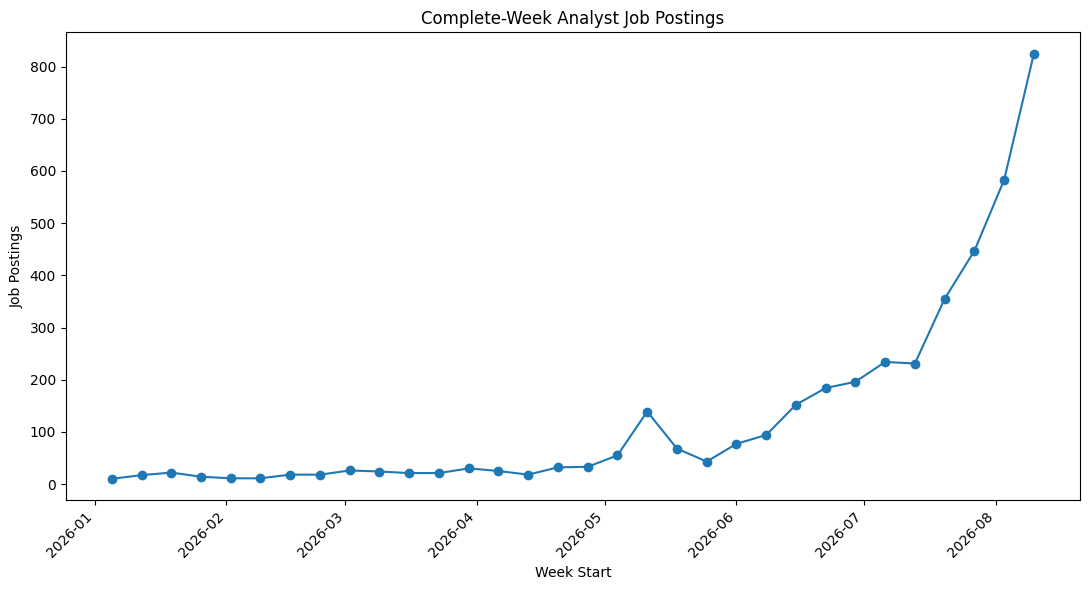

In [13]:
complete_jobs = jobs.loc[
    jobs["is_complete_week"]
].copy()

weekly_jobs = (
    complete_jobs.groupby("week_start")
    .size()
    .reset_index(name="weekly_jobs")
    .sort_values("week_start")
)

weekly_jobs["prior_week_jobs"] = (
    weekly_jobs["weekly_jobs"].shift(1)
)

weekly_jobs["week_over_week_pct"] = (
    (
        weekly_jobs["weekly_jobs"]
        - weekly_jobs["prior_week_jobs"]
    )
    / weekly_jobs["prior_week_jobs"]
    * 100
)

display(weekly_jobs)

plt.figure(figsize=(11, 6))
plt.plot(
    weekly_jobs["week_start"],
    weekly_jobs["weekly_jobs"],
    marker="o",
)
plt.title("Complete-Week Analyst Job Postings")
plt.xlabel("Week Start")
plt.ylabel("Job Postings")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "09_weekly_job_demand.png", dpi=160, bbox_inches="tight")
plt.show()


## 13. Weekly skill shares, 3-week rolling averages, and descriptive slopes


,skill,complete_weeks,percentage_point_change_per_week,direction
4,Tableau,32,0.247926,Upward
1,Power BI,32,0.102361,Upward
0,Excel,32,0.081964,Upward
2,Python,32,0.024371,Approximately Flat
3,SQL,32,0.008167,Approximately Flat


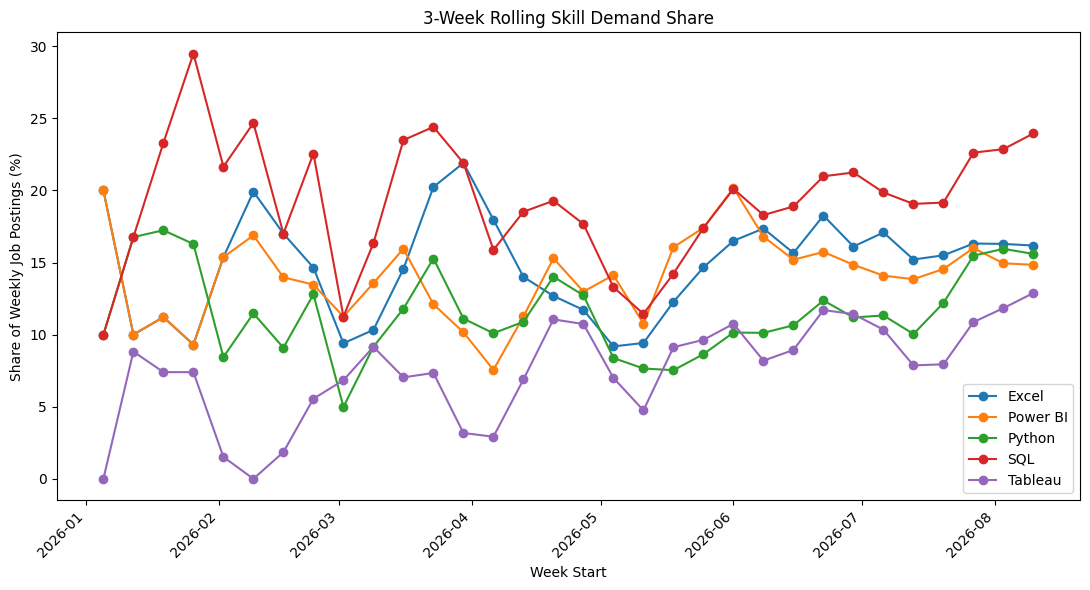

In [14]:
complete_week_totals = (
    complete_jobs.groupby("week_start")
    .size()
    .rename("weekly_jobs")
    .reset_index()
)

complete_skill_rows = (
    skills.merge(
        complete_jobs[
            [
                "job_id",
                "week_start",
            ]
        ],
        on="job_id",
        how="inner",
    )
)

weekly_skill = (
    complete_skill_rows
    .groupby(["week_start", "skill"])["job_id"]
    .nunique()
    .reset_index(name="skill_jobs")
    .merge(
        complete_week_totals,
        on="week_start",
        how="left",
    )
)

weekly_skill["skill_share_pct"] = (
    weekly_skill["skill_jobs"]
    / weekly_skill["weekly_jobs"]
    * 100
)

all_complete_weeks = (
    complete_week_totals["week_start"]
    .sort_values()
    .drop_duplicates()
)

tracked_skills = [
    skill
    for skill in [
        "SQL",
        "Excel",
        "Power BI",
        "Python",
        "Tableau",
    ]
    if skill in set(skills["skill"])
]

grid = pd.MultiIndex.from_product(
    [
        all_complete_weeks,
        tracked_skills,
    ],
    names=[
        "week_start",
        "skill",
    ],
).to_frame(index=False)

tracked_weekly = (
    grid.merge(
        weekly_skill[
            [
                "week_start",
                "skill",
                "skill_jobs",
                "weekly_jobs",
                "skill_share_pct",
            ]
        ],
        on=[
            "week_start",
            "skill",
        ],
        how="left",
    )
    .merge(
        complete_week_totals,
        on="week_start",
        how="left",
        suffixes=("", "_total"),
    )
)

tracked_weekly["skill_jobs"] = (
    tracked_weekly["skill_jobs"].fillna(0)
)

tracked_weekly["weekly_jobs"] = (
    tracked_weekly["weekly_jobs"]
    .fillna(tracked_weekly["weekly_jobs_total"])
)

tracked_weekly["skill_share_pct"] = (
    tracked_weekly["skill_jobs"]
    / tracked_weekly["weekly_jobs"]
    * 100
)

tracked_weekly = tracked_weekly.sort_values(
    ["skill", "week_start"]
)

tracked_weekly["rolling_3_week_share_pct"] = (
    tracked_weekly
    .groupby("skill")["skill_share_pct"]
    .transform(
        lambda s: s.rolling(
            window=3,
            min_periods=1,
        ).mean()
    )
)

slope_rows = []

for skill, frame in tracked_weekly.groupby("skill"):
    frame = frame.sort_values("week_start").copy()
    x = np.arange(len(frame), dtype=float)
    y = frame["skill_share_pct"].to_numpy(dtype=float)

    slope = (
        np.polyfit(x, y, 1)[0]
        if len(frame) >= 2
        else np.nan
    )

    if pd.isna(slope):
        direction = "Not Available"
    elif slope > 0.05:
        direction = "Upward"
    elif slope < -0.05:
        direction = "Downward"
    else:
        direction = "Approximately Flat"

    slope_rows.append(
        {
            "skill": skill,
            "complete_weeks": len(frame),
            "percentage_point_change_per_week": slope,
            "direction": direction,
        }
    )

skill_trends = (
    pd.DataFrame(slope_rows)
    .sort_values(
        "percentage_point_change_per_week",
        ascending=False,
    )
)

display(skill_trends)

plt.figure(figsize=(11, 6))
for skill, frame in tracked_weekly.groupby("skill"):
    plt.plot(
        frame["week_start"],
        frame["rolling_3_week_share_pct"],
        marker="o",
        label=skill,
    )

plt.title("3-Week Rolling Skill Demand Share")
plt.xlabel("Week Start")
plt.ylabel("Share of Weekly Job Postings (%)")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "10_weekly_skill_trend.png", dpi=160, bbox_inches="tight")
plt.show()


## 14. Recent 90-day market comparison


In [15]:
jobs["market_period"] = np.where(
    jobs["is_recent_90d"],
    "Recent 90 Days",
    "Pre-90-Day Period",
)

period_role = (
    jobs.groupby(["market_period", "role_family"])
    .size()
    .reset_index(name="job_count")
)

period_role["share_pct"] = (
    period_role["job_count"]
    / period_role.groupby("market_period")["job_count"].transform("sum")
    * 100
)

recent_role = (
    period_role.loc[
        period_role["market_period"].eq("Recent 90 Days")
    ][["role_family", "share_pct"]]
    .rename(columns={"share_pct": "recent_share_pct"})
)

pre_role = (
    period_role.loc[
        period_role["market_period"].eq("Pre-90-Day Period")
    ][["role_family", "share_pct"]]
    .rename(columns={"share_pct": "pre_share_pct"})
)

role_shift = (
    recent_role.merge(
        pre_role,
        on="role_family",
        how="outer",
    )
    .fillna(0)
)

role_shift["share_change_pp"] = (
    role_shift["recent_share_pct"]
    - role_shift["pre_share_pct"]
)

role_shift = role_shift.sort_values(
    "share_change_pp",
    ascending=False,
)

display(role_shift)

period_skill = (
    skills.merge(
        jobs[
            [
                "job_id",
                "market_period",
            ]
        ],
        on="job_id",
        how="inner",
    )
    .groupby(["market_period", "skill"])["job_id"]
    .nunique()
    .reset_index(name="skill_jobs")
)

period_totals = (
    jobs.groupby("market_period")
    .size()
    .rename("period_jobs")
    .reset_index()
)

period_skill = period_skill.merge(
    period_totals,
    on="market_period",
    how="left",
)

period_skill["skill_share_pct"] = (
    period_skill["skill_jobs"]
    / period_skill["period_jobs"]
    * 100
)

display(
    period_skill.sort_values(
        ["skill", "market_period"]
    ).head(100)
)


,role_family,recent_share_pct,pre_share_pct,share_change_pp
7,Operations / Process Analytics,8.793103,4.324324,4.468779
12,Reporting / MIS Analyst,3.160920,1.441441,1.719478
8,Other Analyst,9.770115,8.648649,1.121466
13,Risk / Quantitative Analytics,4.482759,3.423423,1.059335
4,Data Quality / Governance,2.988506,2.162162,0.826344
11,Product Analyst,3.333333,2.702703,0.630631
0,Analytics Analyst,1.465517,0.900901,0.564616
5,Insights / Customer Analytics,0.459770,0.180180,0.279590
1,BI Analyst,4.396552,4.504505,-0.107953
6,Marketing Analytics,0.804598,1.081081,-0.276483


,market_period,skill,skill_jobs,period_jobs,skill_share_pct
0,Pre-90-Day Period,A/B Testing,6,555,1.081081
40,Recent 90 Days,A/B Testing,68,3480,1.954023
1,Pre-90-Day Period,AWS,10,555,1.801802
41,Recent 90 Days,AWS,131,3480,3.764368
2,Pre-90-Day Period,Airflow,1,555,0.180180
42,Recent 90 Days,Airflow,13,3480,0.373563
3,Pre-90-Day Period,Alteryx,4,555,0.720721
43,Recent 90 Days,Alteryx,56,3480,1.609195
4,Pre-90-Day Period,Azure,18,555,3.243243
44,Recent 90 Days,Azure,145,3480,4.166667


## 15. Export analytical summaries


In [16]:
def money_lakh(value):
    if pd.isna(value):
        return "NA"
    return f"₹{value / 100000:.2f}L"

top_role = role_demand.iloc[0]
top_skill = skill_counts.iloc[0]

top_city_text = "NA"
if not city_demand.empty:
    top_city = city_demand.iloc[0]
    top_city_text = (
        f"{top_city['city']} "
        f"({int(top_city['job_count']):,} postings)"
    )

sql_n = len(sql_salary)
non_sql_n = len(non_sql_salary)

findings = [
    PROJECT_TITLE,
    "=" * len(PROJECT_TITLE),
    "",
    f"Analytical vacancies: {len(jobs):,}",
    f"Job-skill rows: {len(skills):,}",
    f"Unique skills: {skills['skill'].nunique():,}",
    f"Skill extraction coverage: {jobs['has_extracted_skill'].mean() * 100:.2f}%",
    f"Experience extraction coverage: {jobs['experience_min_years'].notna().mean() * 100:.2f}%",
    f"Salary analysis coverage: {jobs['salary_analysis_eligible'].mean() * 100:.2f}%",
    "",
    f"Top role family: {top_role['role_family']} ({int(top_role['job_count']):,} postings)",
    f"Top skill: {top_skill['skill']} ({int(top_skill['job_count']):,} postings)",
    f"Top specific city: {top_city_text}",
    "",
    f"Salary observations: {len(salary_jobs):,}",
    f"Salary median: {money_lakh(salary_jobs['salary_midpoint'].median())}",
    f"Salary mean: {money_lakh(salary_jobs['salary_midpoint'].mean())}",
    f"Salary minimum: {money_lakh(salary_jobs['salary_midpoint'].min())}",
    f"Salary maximum: {money_lakh(salary_jobs['salary_midpoint'].max())}",
    "",
    f"SQL salary observations: {sql_n:,}",
    f"Non-SQL salary observations: {non_sql_n:,}",
    f"Observed SQL minus non-SQL median difference: {money_lakh(observed_sql_median_difference)}",
    f"Bootstrap 95% CI: {money_lakh(ci_low)} to {money_lakh(ci_high)}",
    f"Bootstrap conclusion: {'Inconclusive because the interval includes zero' if ci_low <= 0 <= ci_high else 'Interval excludes zero; descriptive association only'}",
    "",
    "Trend slopes are descriptive short-window signals and are not forecasts.",
    "Salary associations are descriptive and are not causal claims.",
]

findings_path = REPORTS_DIR / "final_findings.txt"
findings_path.write_text(
    "\n".join(findings) + "\n",
    encoding="utf-8",
)

role_demand.to_csv(
    REPORTS_DIR / "role_demand_summary.csv",
    index=False,
)

city_demand.to_csv(
    REPORTS_DIR / "city_demand_summary.csv",
    index=False,
)

company_demand.to_csv(
    REPORTS_DIR / "company_demand_summary.csv",
    index=False,
)

skill_counts.to_csv(
    REPORTS_DIR / "skill_demand_summary.csv",
    index=False,
)

skill_pairs.to_csv(
    REPORTS_DIR / "skill_pair_summary.csv",
    index=False,
)

qualifying_skill_salary.to_csv(
    REPORTS_DIR / "skill_salary_summary.csv",
    index=False,
)

skill_trends.to_csv(
    REPORTS_DIR / "skill_trend_summary.csv",
    index=False,
)

role_shift.to_csv(
    REPORTS_DIR / "recent_role_shift_summary.csv",
    index=False,
)

print("Saved:")
print(findings_path)
print(FIGURE_DIR)


Saved:
C:\Users\kvina\Downloads\Data Analyst Job Market Intelligence Skill, Experience and Salary Analytics — India\Data Analyst Job Market Intelligence Skill, Experience and Salary Analytics — India\reports\final_findings.txt
C:\Users\kvina\Downloads\Data Analyst Job Market Intelligence Skill, Experience and Salary Analytics — India\Data Analyst Job Market Intelligence Skill, Experience and Salary Analytics — India\reports\figures


## 16. Final analytical interpretation

Use the generated tables, `reports/final_findings.txt`, and exported figures as the source for the Power BI dashboard and resume discussion.

When presenting the project:
- separate market-demand findings from salary findings;
- state the salary sample size and coverage whenever discussing salary;
- describe bootstrap results using the confidence interval;
- describe trend slopes as short-window signals;
- avoid causal language for observational job-posting data.
